# Comprension EDA - CustomerChurnX

Este notebook desarrolla el analisis exploratorio del dataset de churn. Su objetivo es entender la estructura de la base, revisar la distribucion de la variable objetivo y detectar patrones utiles para el feature engineering y la seleccion del modelo.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

candidates = [
    Path.cwd() / "Base_de_datos.csv",
    Path.cwd().parent / "Base_de_datos.csv",
    Path.cwd() / "mlops_pipeline" / "Base_de_datos.csv",
]
DATA_PATH = next((path for path in candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("No se encontro Base_de_datos.csv desde el directorio actual")
ROOT = DATA_PATH.parent
DATA_PATH

sns.set_theme(style="whitegrid")
df = pd.read_csv(DATA_PATH)
df.head()

,customer_id,signup_month,age,tenure_months,region,channel,plan,sessions_week,avg_session_min,notif_click_rate,support_tickets_3m,discount_pct_3m,late_payments_6m,auto_renew,churn
0,C100000,10,71,49,South,web,Basic,4,10.11,0.318,0,0.138,0,1,0
1,C100001,22,53,44,West,store,Basic,3,6.55,0.329,0,0.000,0,0,0
2,C100002,10,56,51,South,web,Basic,6,12.10,0.120,0,0.001,1,1,0
3,C100003,22,69,48,Center,app,Basic,5,11.01,0.237,0,0.041,0,1,0
4,C100004,20,50,7,South,app,Basic,7,12.97,0.145,0,0.183,0,1,0


## Exploracion inicial

Primero se revisa el tamano de la base, el nivel de churn y un resumen estadistico general. Esto permite verificar si la muestra es suficiente y si existe desbalance en la variable objetivo.

In [2]:
display(df.describe(include="all").T)
print("Shape:", df.shape)
print("Target churn rate:", round(df["churn"].mean(), 4))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,5000,5000,C100000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_month,5000.0,NaN,NaN,NaN,12.589,6.987349,1.0,6.0,13.0,19.0,24.0
age,5000.0,NaN,NaN,NaN,46.2824,16.330021,18.0,32.0,46.0,61.0,74.0
tenure_months,5000.0,NaN,NaN,NaN,35.5612,20.579567,1.0,18.0,35.0,53.0,71.0
region,5000,5,Center,1310,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel,5000,3,app,2453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
plan,5000,3,Basic,2274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sessions_week,5000.0,NaN,NaN,NaN,5.0276,2.238803,0.0,3.0,5.0,6.0,14.0
avg_session_min,5000.0,NaN,NaN,NaN,12.044738,4.011593,1.0,9.31,12.0,14.7525,26.85
notif_click_rate,5000.0,NaN,NaN,NaN,0.183255,0.113473,0.0,0.1,0.179,0.25825,0.595


Shape: (5000, 15)
Target churn rate: 0.2436


In [3]:
pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "nulos_pct": (df.isna().mean() * 100).round(2),
    "unicos": df.nunique()
})

,dtype,nulos,nulos_pct,unicos
customer_id,str,0,0.0,5000
signup_month,int64,0,0.0,24
age,int64,0,0.0,57
tenure_months,int64,0,0.0,71
region,str,0,0.0,5
channel,str,0,0.0,3
plan,str,0,0.0,3
sessions_week,int64,0,0.0,15
avg_session_min,float64,0,0.0,1591
notif_click_rate,float64,0,0.0,495


## Caracterizacion de variables

- Numericas continuas: `avg_session_min`, `notif_click_rate`, `discount_pct_3m`.
- Numericas discretas: `age`, `tenure_months`, `signup_month`, `sessions_week`, `support_tickets_3m`, `late_payments_6m`.
- Categoricas nominales: `region`, `channel`, `plan`.
- Binarias: `auto_renew`, `churn`.
- Identificador no predictivo: `customer_id`.

Esta separacion ayuda a decidir el tipo de analisis y el preprocesamiento posterior.

## Analisis univariable

En esta parte se observa la distribucion individual de cada variable. El objetivo es detectar sesgos, dispersion, posibles outliers y diferencias de escala antes de entrenar el modelo.

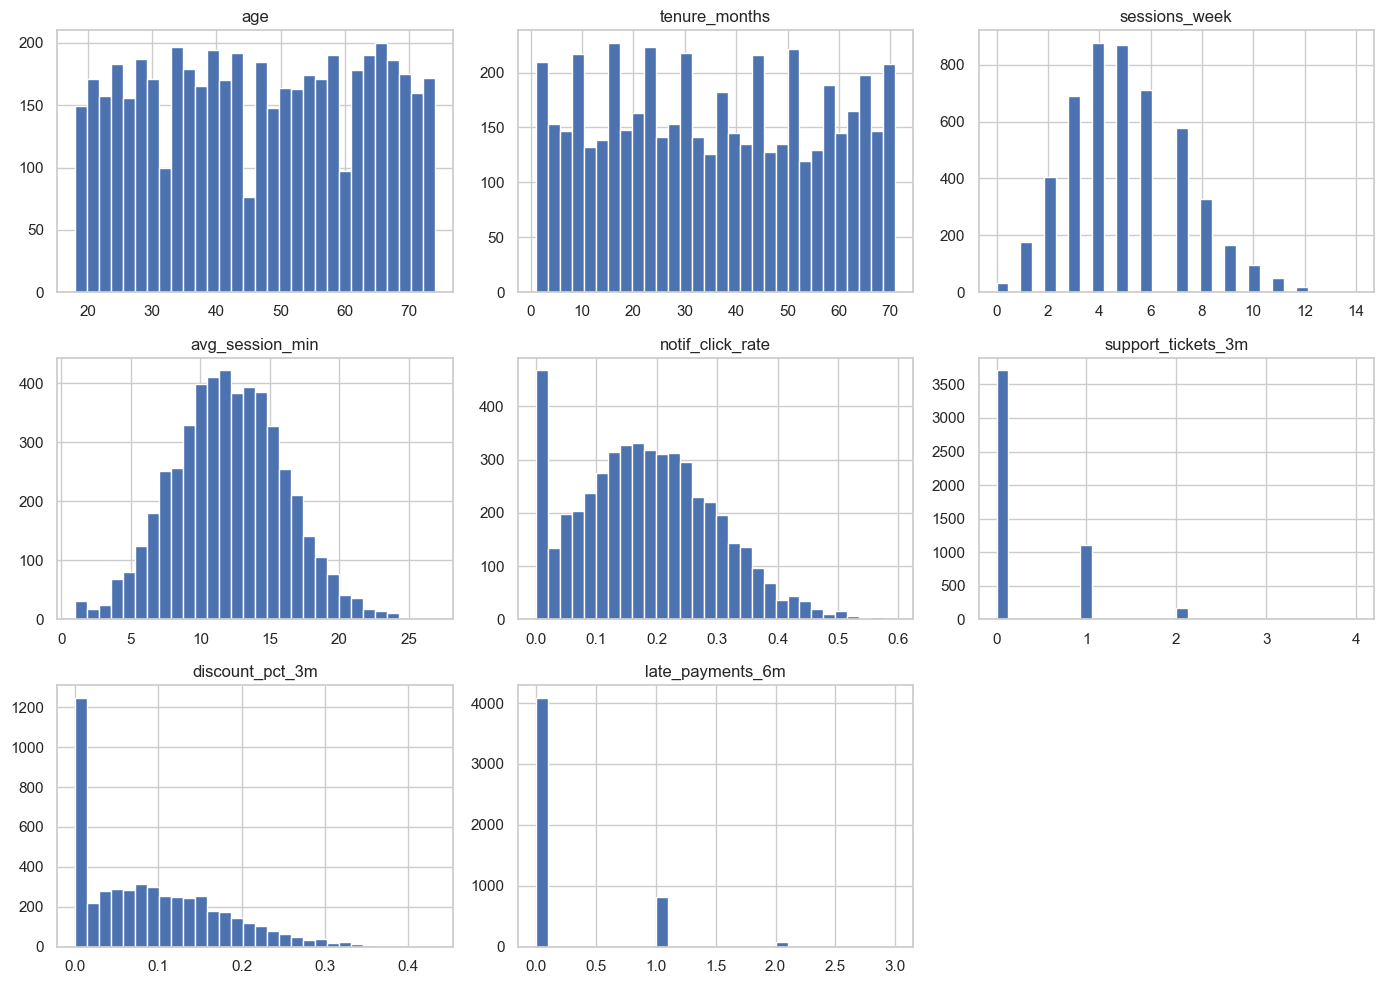

In [4]:
numeric_cols = ["age", "tenure_months", "sessions_week", "avg_session_min", "notif_click_rate", "support_tickets_3m", "discount_pct_3m", "late_payments_6m"]
df[numeric_cols].hist(figsize=(14, 10), bins=30)
plt.tight_layout()

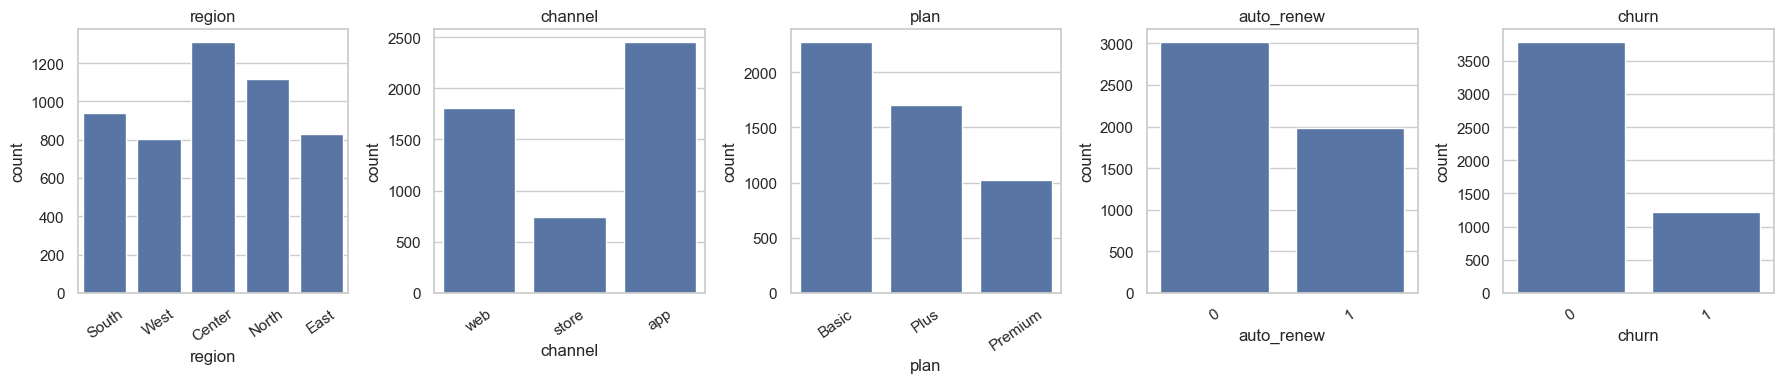

In [5]:
categorical_cols = ["region", "channel", "plan", "auto_renew", "churn"]
fig, axes = plt.subplots(1, len(categorical_cols), figsize=(18, 4))
for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()

## Analisis bivariable respecto al objetivo

Aqui se compara cada variable importante contra `churn` para identificar relaciones utiles. Este paso ayuda a encontrar segmentos con mas riesgo y senales que puedan transformarse en features.

In [6]:
churn_by_cat = {}
for col in ["region", "channel", "plan", "auto_renew"]:
    churn_by_cat[col] = df.groupby(col)["churn"].agg(["count", "mean"]).sort_values("mean", ascending=False)
    display(churn_by_cat[col])

,count,mean
region,,
South,938,0.262260
Center,1310,0.253435
North,1116,0.248208
East,832,0.224760
West,804,0.218905


,count,mean
channel,,
store,740,0.263514
app,2453,0.240522
web,1807,0.239624


,count,mean
plan,,
Basic,2274,0.266491
Plus,1704,0.248239
Premium,1022,0.184932


,count,mean
auto_renew,,
0,3017,0.269804
1,1983,0.203732


## Resumen numerico de hallazgos

Esta tabla resume diferencias promedio entre clientes con y sin churn. Tambien muestra la tasa de churn por `plan`, `channel` y `auto_renew`, lo que permite sostener con evidencia las decisiones del feature engineering.

In [7]:
summary_by_target = df.groupby('churn')[[
    'age',
    'tenure_months',
    'sessions_week',
    'avg_session_min',
    'notif_click_rate',
    'support_tickets_3m',
    'discount_pct_3m',
    'late_payments_6m'
]].mean().round(3)

segment_summary = {
    'churn_por_plan': df.groupby('plan')['churn'].mean().round(4),
    'churn_por_channel': df.groupby('channel')['churn'].mean().round(4),
    'churn_por_auto_renew': df.groupby('auto_renew')['churn'].mean().round(4),
}

display(summary_by_target)
for name, table in segment_summary.items():
    print(f'\n{name}')
    display(table)

,age,tenure_months,sessions_week,avg_session_min,notif_click_rate,support_tickets_3m,discount_pct_3m,late_payments_6m
churn,,,,,,,,
0,47.272,38.123,5.196,12.120,0.188,0.264,0.095,0.189
1,43.210,27.605,4.504,11.811,0.167,0.401,0.088,0.241



churn_por_plan


plan
Basic      0.2665
Plus       0.2482
Premium    0.1849
Name: churn, dtype: float64


churn_por_channel


channel
app      0.2405
store    0.2635
web      0.2396
Name: churn, dtype: float64


churn_por_auto_renew


auto_renew
0    0.2698
1    0.2037
Name: churn, dtype: float64

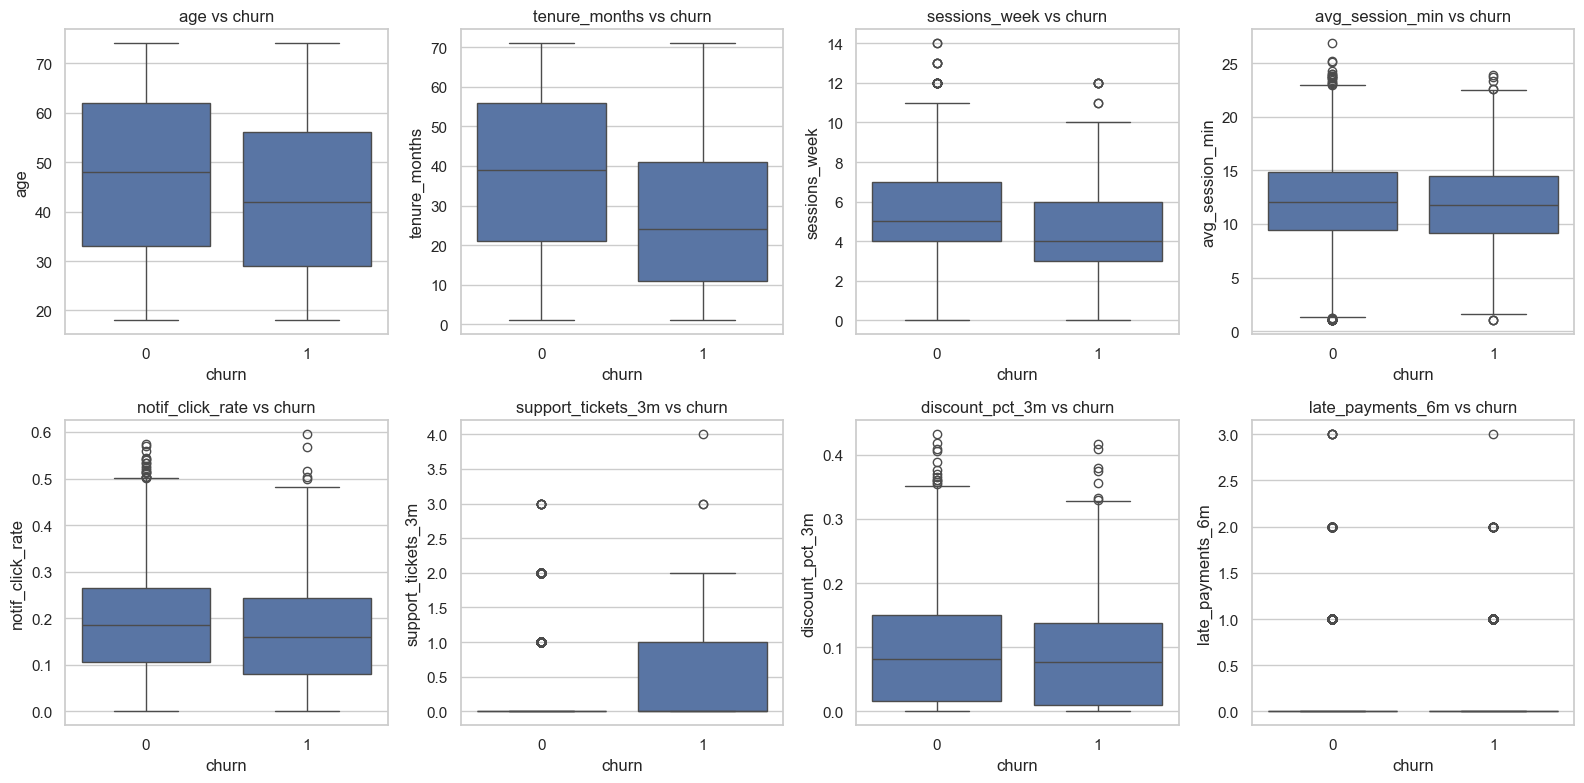

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.boxplot(data=df, x="churn", y=col, ax=ax)
    ax.set_title(f"{col} vs churn")
plt.tight_layout()

## Analisis multivariable

Luego se revisan relaciones entre varias variables al mismo tiempo. La matriz de correlacion y la tabla cruzada por `plan` y `channel` ayudan a entender dependencias y posibles combinaciones de riesgo.

Text(0.5, 1.0, 'Matriz de correlaci?n')

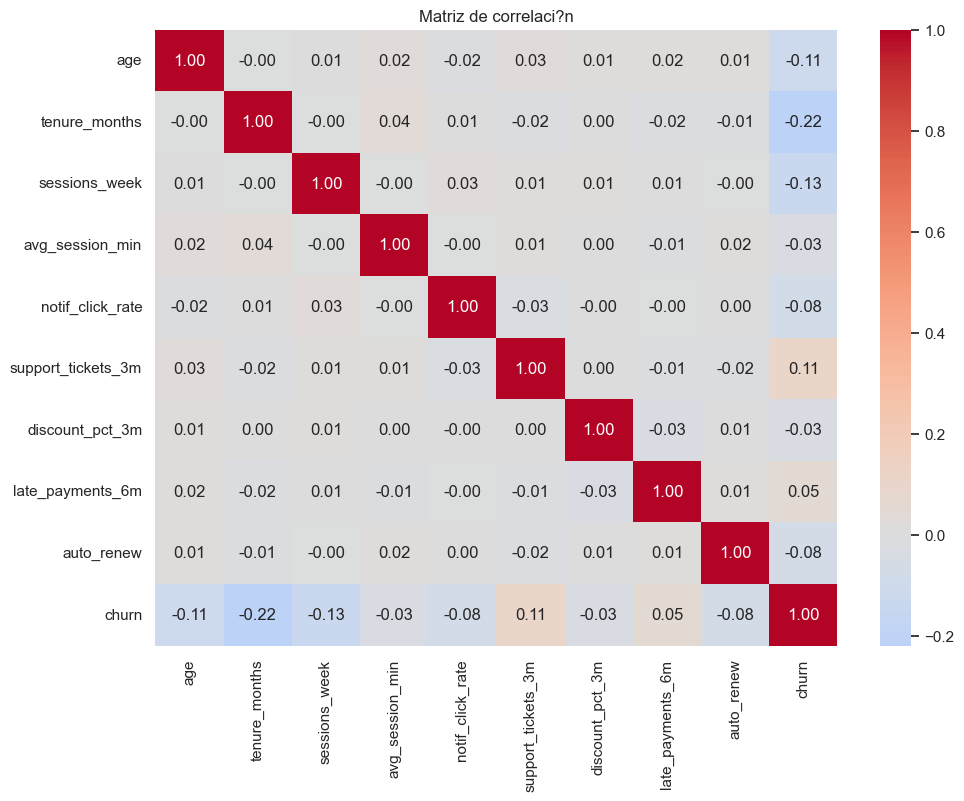

In [9]:
corr = df[numeric_cols + ["auto_renew", "churn"]].corr(numeric_only=True)
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlaci?n")

In [10]:
pivot = pd.pivot_table(df, values="churn", index="plan", columns="channel", aggfunc="mean")
pivot

channel,app,store,web
plan,,,
Basic,0.261780,0.303571,0.257576
Plus,0.238443,0.251012,0.259843
Premium,0.193814,0.197452,0.168421


## Hallazgos y decisiones para feature engineering

Hallazgos principales observados en la base:

- La tasa general de churn es 24.36 por ciento, por lo que existe desbalance moderado pero no extremo.
- Los clientes con churn presentan menor antiguedad promedio y menor actividad semanal que los clientes que permanecen.
- `support_tickets_3m` y `late_payments_6m` muestran relacion positiva con churn: a mayor friccion operativa, mayor riesgo.
- El plan `Premium` presenta menor churn promedio que `Basic`, y los clientes sin renovacion automatica muestran mas abandono que quienes si la tienen.
- `customer_id` no debe entrar al modelo porque solo identifica al cliente y no aporta capacidad predictiva.

Decisiones tomadas a partir del EDA:

- Codificar las variables categoricas con One-Hot Encoding.
- Crear variables derivadas como minutos de uso semanal, tickets por antiguedad, bandera de mora, descuento alto y baja interaccion.
- Priorizar metricas como ROC-AUC, recall y F1 para evaluar el modelo de churn.
- Comparar ventanas historicas y recientes por `signup_month` para monitoreo de drift.